In [56]:
import numpy as np
import matplotlib.pyplot as plt

from png2webp import convert_png_to_webp

In [57]:
img_file_png = "../images/market_demand.png"
img_file_webp = img_file_png.replace('.png', '.webp')


In [ ]:
def plot_market_demand_forecast(
    n_history: int = 30,
    n_forecast: int = 20,
    seed: int = 42,
    img_loc: str = img_file_png,
) -> None:
    """
    Plot historical market demand with a forecast confidence interval
    and save the figure to disk.

    Parameters
    ----------
    n_history : int
        Number of historical time steps.
    n_forecast : int
        Number of forecast time steps.
    seed : int
        Random seed for reproducibility.
    img_loc : str
        Path where the image will be saved.

    Returns
    -------
    None
    """
    rng = np.random.default_rng(seed)

    # --- time axis ---
    time_history = np.arange(n_history)
    time_forecast = np.arange(n_history, n_history + n_forecast)

    # --- historical demand ---
    demand_history = (
        50
        + 1.01 * time_history
        + rng.normal(0, 1.5, size=n_history)
    )

    # --- forecast mean ---
    last_value = demand_history[-1]
    trend = 1.05
    demand_forecast_mean = last_value + trend * np.arange(1, n_forecast + 1)

    # --- confidence interval ---
    uncertainty = 3 + 0.6 * np.arange(1, n_forecast + 1)
    lower_bound = demand_forecast_mean - uncertainty
    upper_bound = demand_forecast_mean + uncertainty

    # --- plot ---
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        time_history,
        demand_history,
        linewidth=2.5,
        label="Historical Demand",
    )

    ax.fill_between(
        time_forecast,
        lower_bound,
        upper_bound,
        alpha=0.25,
        label="Forecast Demand (Prediction Interval)",
    )

    ax.axvline(
        x=n_history - 0.5,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    ax.set_xlabel("Time", fontsize=16)
    ax.set_ylabel("Market Demand", fontsize=16)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.2)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.legend(
        loc="lower right",
        frameon=False,
        bbox_to_anchor=(0.98, 0.02),
    )

    fig.tight_layout()
    fig.subplots_adjust(left=0.1, bottom=0.2, right=0.08)
    fig.savefig(
        img_loc,
        dpi=300,
        #bbox_inches="tight",
        #pad_inches=0.3
    )

    plt.show()
    plt.close(fig)


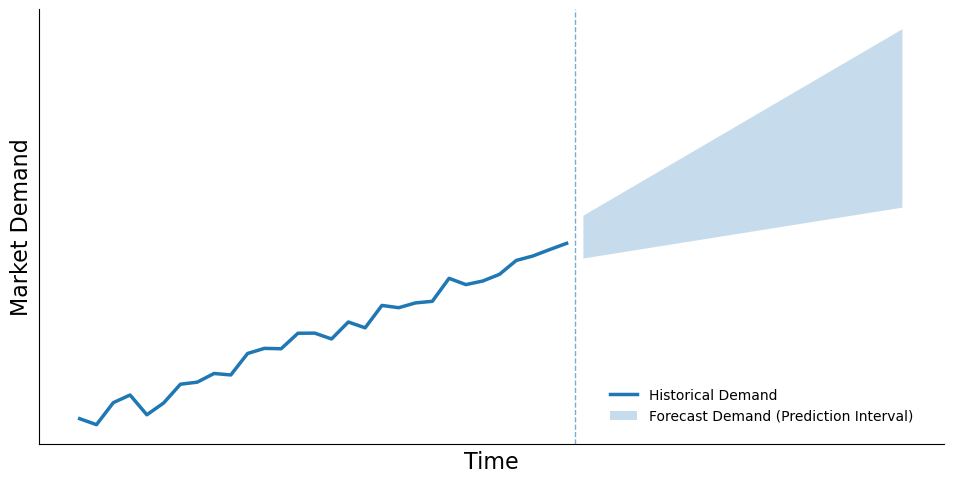

In [128]:
plot_market_demand_forecast()

In [129]:
convert_png_to_webp(img_file_png, img_file_webp)

Successfully converted '../images/market_demand.png' to '../images/market_demand.webp'
